# Sprint 5 Report – Resampling and Ensemble Techniques
**Course:** Data Intensive Systems (4DV652)  
**Lab:** Lab Lecture 5  
**Deadline:** 2026-02-25  

---

## Overview

This sprint focused on applying **heterogeneous ensemble methods** and **stacking** to challenge the current regression and classification champions established in Sprint 4. The team worked across three parallel tracks:

- **Weighted Regression** - by aligning the coloumns of the regression with the classification to built a weighted RandomForest based on the classification predictions as feature weights. Yet, this performs much worse then the raw prediction.
- **Regression Ensemble** – Predict `AimoScore` (continuous target) using diverse base models with bootstrap sampling and aggregation strategies.
- **Classification Ensemble** – Predict `WeakestLink` (14-class target) using voting classifiers.

A custom `CorrelationFilter` transformer was also implemented as a reusable sklearn-compatible preprocessing component shared across both tracks.

---

## 0. Software Development: CorrelationFilter

A custom `sklearn`-compatible transformer was implemented and used in both the regression and classification pipelines. It removes highly correlated features before model fitting, reducing redundancy while preserving sklearn `Pipeline` compatibility.

This CorrelationFilter is shared as `CorrelationFilter.py` between the development and the deployment of pickled models in the huggingface space.

## 1. ML Process Iteration

### 1.1 Problem Framing Recap

The dataset originates from movement quality assessments (NASM Overhead Squat Assessment). Two supervised learning tasks are defined:

| Task | Target | Type | Sprint 4 Champion Score |
|------|--------|------|-------------------------|
| Regression | `AimoScore` (continuous) | Regression | R² = 0.6356, RMSE = 0.1303 |
| Classification | `WeakestLink` (14 classes) | Multiclass | Weighted F1 = 0.6110 |

### 1.2 Sprint 5 Goals

Per the lab assignment:
1. Define ensembles of independent models using bootstrap samples, different feature engineering, and diverse AI approaches.
2. Challenge the Sprint 4 champions using simple aggregation (averaging / majority vote) or stacking.
3. Deploy a new champion if the ensemble outperforms the previous one.
4. Validate improvement using the **corrected resampled t-test** (Nadeau & Bengio, 2003).

### 1.3 Progess chart

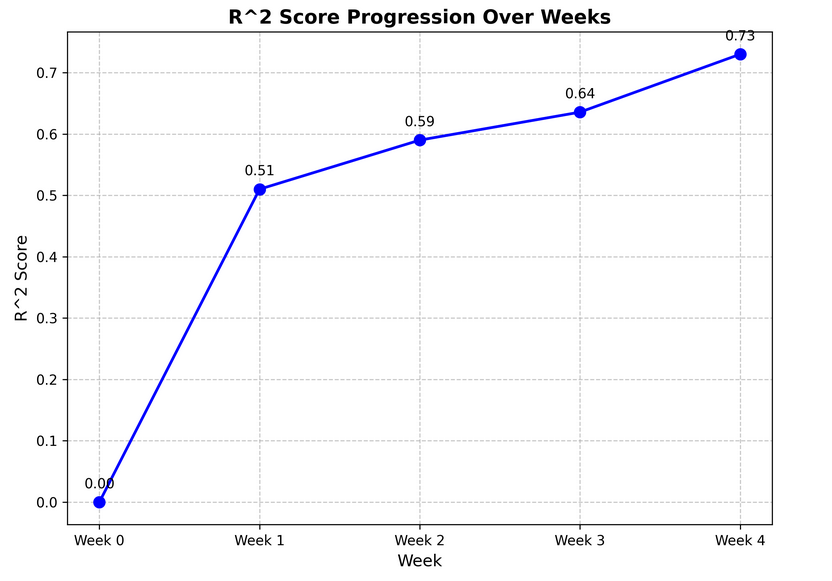
---


## 3. Regression Ensemble (A5_Regression_Ensemble)

### 3.1 Approach

A heterogeneous ensemble was designed following the sprint lecture pattern:

- **Bootstrap diversity**: Four different bootstrap-augmented training sets (`dataset2_train_augmented_1..4.csv`).
- **Model diversity**: Four distinct regressors (Lasso, Ridge, RandomForest, GradientBoosting), each trained on a different bootstrap sample.
- **Feature diversity**: Feature subsets were defined (full, angle-only, NASM-only, angle+NASM) to allow further differentiation.
- **Aggregation**: Two strategies — simple averaging and CV-R²-weighted averaging.

### 3.2 Results

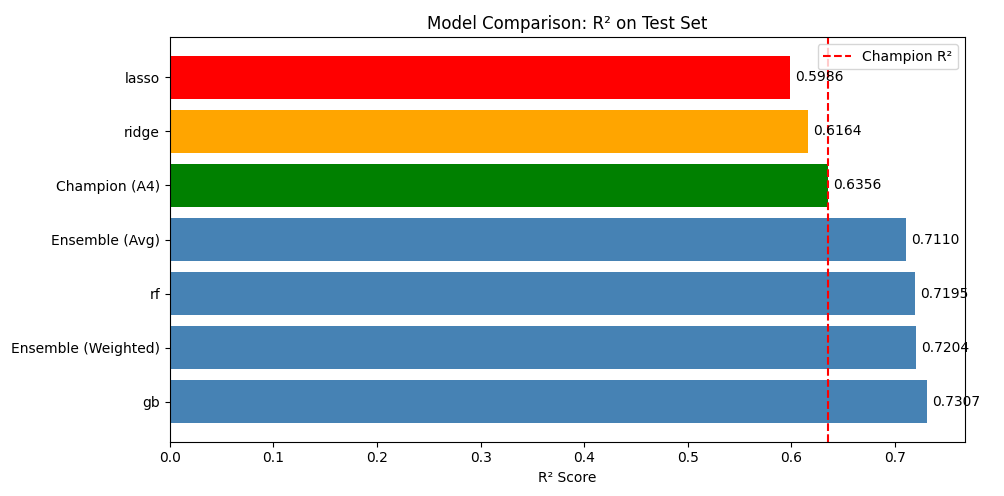

### 3.3 Summary

Base models trained: 4
  - Lasso, Ridge, RandomForest, GradientBoosting
  - Each trained on different bootstrap sample

Ensemble methods tested:
  - Simple averaging: R²=0.7110
  - Weighted averaging: R²=0.7204

Current champion: R²=0.6356

Statistical significance (α=0.05):
  - Simple Avg vs Champion: p=0.5016 (Not significant)
  - Weighted Avg vs Champion: p=0.5241 (Not significant)

---

## 4. Classification Ensemble (A5_Classification_Ensemble)

### 4.1 Problem Setup

- **Target**: `WeakestLink` — the movement category with the highest deviation score across 14 NASM categories.
- **Features**: Merged movement features from `aimoscores.csv` + weakest link labels from `scores_and_weaklink.csv`.
- **Class imbalance**: Addressed using `class_weight='balanced'` and `class_weight='balanced_subsample'`.

### 4.2 Ensemble Strategies

Four ensemble strategies were designed and evaluated using **5-fold stratified cross-validation**:

#### Ensemble 1 – Hard Voting
Each base classifier casts a vote; the class with the most votes wins. Base classifiers: Random Forest, Logistic Regression, XGBoost, LightGBM, KNN (k=7), LDA.

#### Ensemble 2 – Soft Voting  
Same base classifiers, but predictions are combined via averaged class probabilities. Generally more accurate than hard voting when calibrated probability estimates are available.

#### Ensemble 3 – Bootstrap Bagging on LDA  
`BaggingClassifier` wrapping `LinearDiscriminantAnalysis` (50 estimators, 80% sample size, 90% feature subset). Demonstrates how bagging can stabilise a weak linear model.

#### Ensemble 4 – Stacking (LR meta-learner)  
Base classifiers: Random Forest, Logistic Regression, KNN, LDA. Meta-learner: `LogisticRegression` trained on out-of-fold predictions (5-fold CV). The meta-learner learns *how to combine* base model outputs, replacing simple voting with a learned aggregation function.

### 4.3 Result

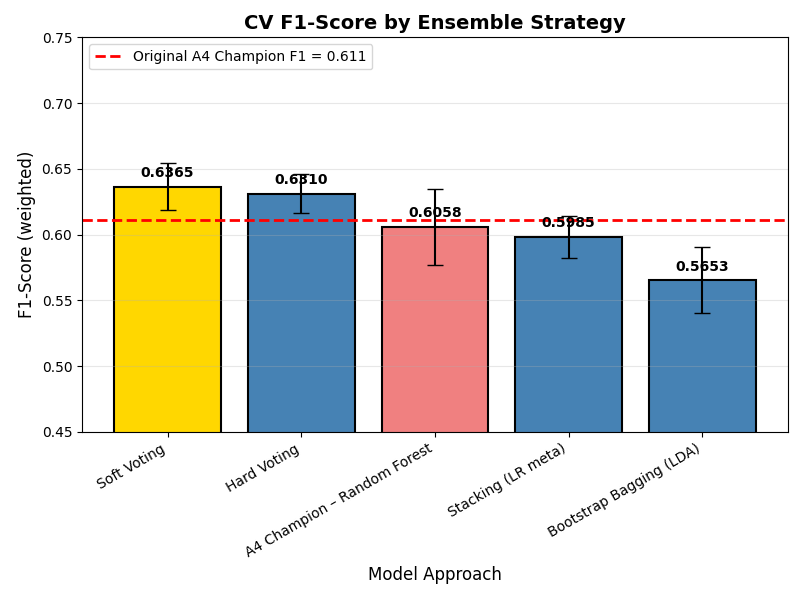

Significance tests vs A4 Champion
-  Hard Voting                          t=+1.339  p=0.2516
-  Soft Voting                          t=+1.632  p=0.1781
-  Bootstrap Bagging (LDA)              t=-5.123  p=0.0069
-  Stacking (LR meta)                   t=-0.556  p=0.6078

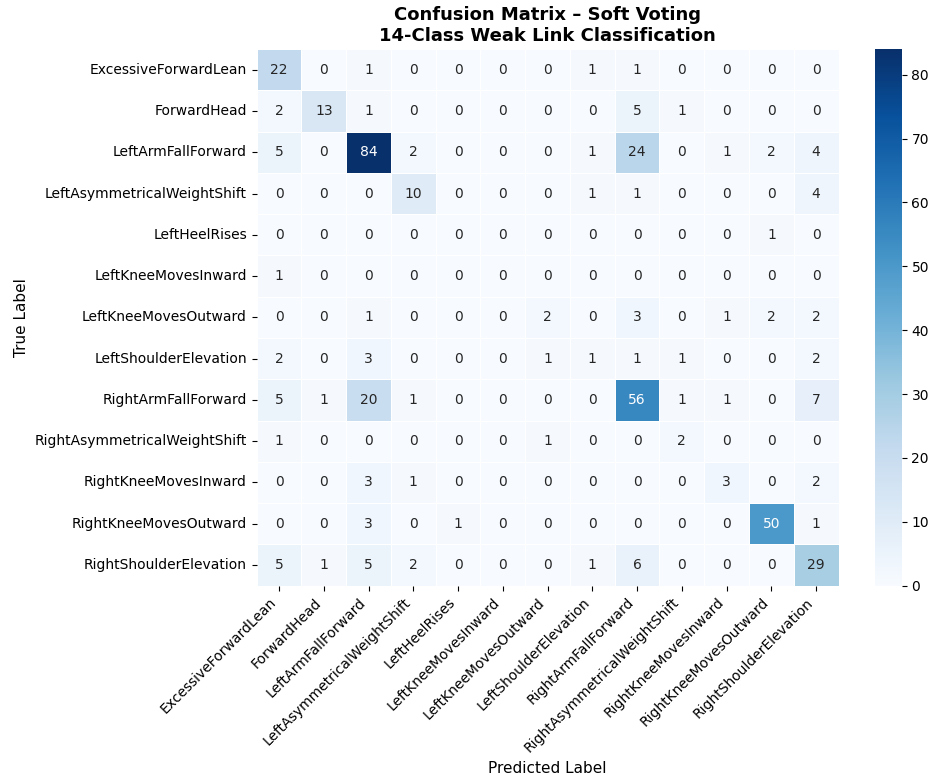

---
## 5. Sprint Summary

### 5.1 What Was Done

| Component | Owner Track | Description |
|-----------|------------|-------------|
| `CorrelationFilter.py` | Shared | Custom sklearn transformer removing highly correlated features |
| Regression Ensemble | Regression track | 4 base models (Lasso, Ridge, RF, GB) × 4 bootstrap samples, simple + weighted averaging |
| Classification Ensemble | Classification track | Hard Voting, Soft Voting, Bagging (LDA), Stacking (LR meta) |
| Statistical Testing | Both tracks | Corrected resampled t-test (Nadeau & Bengio 2003) |
| Champion Deployment | Both tracks | Pickle artifacts saved if ensemble outperforms A4 champion |

### 5.2 Key Design Decisions

**Regression:** Bootstrap-based diversity was the primary source of independence between base models. Weighted averaging was used as the aggregation method with weights derived from CV-R² scores, giving better-performing models proportionally more influence.

**Classification:** A broader range of diversity strategies was explored — algorithm diversity (RF, LR, XGB, LGB, KNN, LDA), voting schemes (hard vs soft), and a stacking approach where a meta-learner replaces manual aggregation. Class imbalance was consistently addressed with `class_weight='balanced'`.

**Statistical rigor:** The Nadeau-Bengio correction was applied in both tracks rather than a naive t-test, accounting for the overlap between cross-validation folds (correction factor ≈ 1.25 for this dataset).

### 5.3 Limitations and Next Steps

- Feature subset diversity (angle-only, NASM-only) was defined but ultimately the final configuration used full features for all base models in the regression track. Future iterations could test whether feature-diverse ensembles further reduce error.
- The classification stacking approach used `passthrough=False`, meaning the meta-learner only sees predicted class probabilities, not the original features. Including raw features (`passthrough=True`) could be explored.
- More ensemble members (e.g., 8–10 base models) could be evaluated to assess the accuracy-variance tradeoff more thoroughly.
- Train a weighted RandomForestRegression